In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bilby.gw.transdimensional_source_models import multi_resonance_model_factory, bns_with_resonances_factory
import bilby

In [2]:
N = 2
resonance_model = multi_resonance_model_factory(N)
f_min = 20.0
sampling_frequency = 2048.0
f_max = sampling_frequency / 2.0
T = 16.0
freqs = np.arange(f_min, f_max, 1.0 / T)

In [3]:
resonance_kwargs = {
    'n': N,
    'f00': 500.0,
    'f01': 800.0,
    'dphi0': 0.5,
    'dphi1': 2.5,
}
resonance_time_series = resonance_model(freqs, **resonance_kwargs)

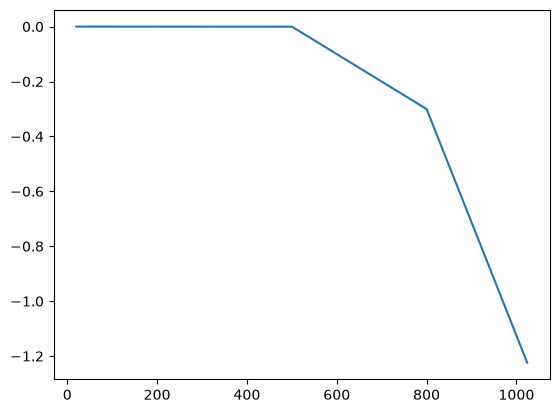

In [4]:
plt.plot(freqs, resonance_time_series)
plt.show()

In [14]:
N = 2
bns_with_resonances = bns_with_resonances_factory(N)

parameter_dict = {
    'mass_1': 1.4,
    'mass_2': 1.0,
    'a_1': 0.02,
    'a_2': 0.01,
    'lambda_1': 400.0,
    'lambda_2': 600.0,
    'tilt_1': 0.0,
    'tilt_2': 0.0,
    'phi_12': 0.0,
    'phi_jl': 0.0,
    'luminosity_distance': 400,  # Mpc
    'theta_jn': np.pi / 3.0,
    'phase': 0.0,
    'n': N,
    'f00': 500.0,
    'f01': 800.0,
    'dphi0': 2.0,
    'dphi1': 1.0,
}

In [15]:
print(parameter_dict.keys())

dict_keys(['mass_1', 'mass_2', 'a_1', 'a_2', 'lambda_1', 'lambda_2', 'tilt_1', 'tilt_2', 'phi_12', 'phi_jl', 'luminosity_distance', 'theta_jn', 'phase', 'n', 'f00', 'f01', 'dphi0', 'dphi1'])


In [16]:
from bilby.gw.source import lal_binary_neutron_star


waveform_arguments = dict(
    minimum_frequency=f_min,
    maximum_frequency=f_max,
)
waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
    duration=T,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bns_with_resonances,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
    parameters=parameter_dict,
)
waveform_generator_no_res = bilby.gw.waveform_generator.WaveformGenerator(
    duration=T,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=lal_binary_neutron_star,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
    parameters=parameter_dict,
)

14:03 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=16.0, sampling_frequency=2048.0, start_time=0, frequency_domain_source_model=bilby.gw.transdimensional_source_models.bns_with_resonances_2components, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'minimum_frequency': 20.0, 'maximum_frequency': 1024.0})
14:03 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=16.0, sampling_frequency=2048.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'minimum_frequency': 20.0, 'maximum_frequency': 1024.0})


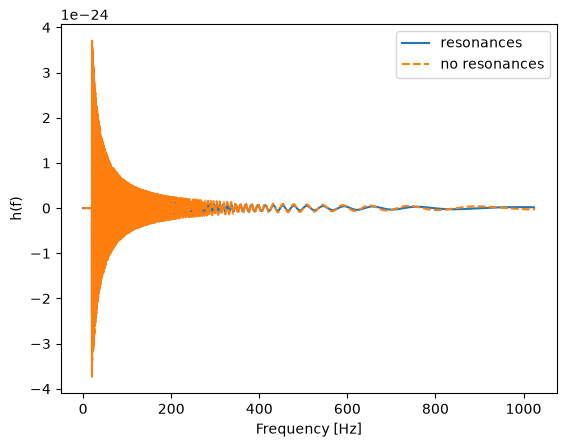

In [17]:
strain = waveform_generator.frequency_domain_strain()
strain_no_res = waveform_generator_no_res.frequency_domain_strain()
f_arr = waveform_generator.frequency_array
plt.plot(f_arr, strain['plus'].real, label='resonances')
plt.plot(f_arr, strain_no_res['plus'].real, label='no resonances', ls='--')
plt.xlabel('Frequency [Hz]')
plt.ylabel('h(f)')
plt.legend()
plt.show()

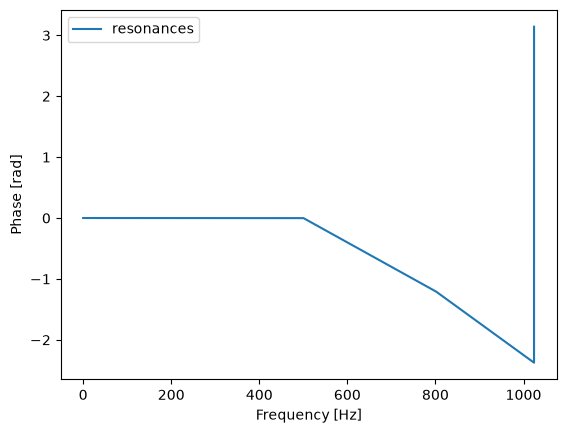

In [18]:
phase_res = np.unwrap(np.angle(strain['plus']))
phase_no_res = np.unwrap(np.angle(strain_no_res['plus']))
plt.plot(f_arr, phase_res - phase_no_res, label='resonances')
# plt.plot(f_arr, phase_no_res, label='no resonances', ls='--')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase [rad]')
plt.legend()
plt.show()